# Customer Churn Prediction: Model Evaluation, ROC Analysis & Feature Importance
### Olist Brazilian E-Commerce Dataset

In this notebook, we:
1. Train 3 classifiers (**Logistic Regression**, **Random Forest**, and **XGBoost**) on the 80/20 train/test split.
2. Generate full **Classification Reports** (Precision, Recall, F1-Score, Support, Accuracy) for each model.
3. Construct an **Academic-Ready Combined ROC Curve Plot** displaying Area Under Curve (AUC) scores.
4. Extract **Feature Importances** from the best-performing tree-based model and provide automated diagnostic interpretation.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_curve, roc_auc_score

# 1. Load Processed Modeling Dataset
model_csv_path = os.path.join("..", "Data", "Processed", "df_churn_model.csv") if os.path.exists(os.path.join("..", "Data", "Processed", "df_churn_model.csv")) else os.path.join("Data", "Processed", "df_churn_model.csv")
df_model = pd.read_csv(model_csv_path, index_col="customer_unique_id")

feature_cols = ["Recency", "Frequency", "Monetary"]
X = df_model[feature_cols]
y = df_model["is_churned"]

# 80/20 Stratified Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Test Set Size: {len(y_test):,} customers")

Test Set Size: 18,672 customers


## 2. Train Models & Print Classification Reports

In [2]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42, eval_metric="logloss")
}

predictions = {}
probabilities = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    predictions[name] = y_pred
    probabilities[name] = y_prob
    
    print("=" * 50)
    print(f"CLASSIFICATION REPORT: {name.upper()}")
    print("=" * 50)
    print(classification_report(y_test, y_pred, target_names=["Retained (0)", "Churned (1)"], digits=4))
    print()

CLASSIFICATION REPORT: LOGISTIC REGRESSION
              precision    recall  f1-score   support

Retained (0)     0.9999    0.9987    0.9993      7729
 Churned (1)     0.9991    0.9999    0.9995     10943

    accuracy                         0.9994     18672
   macro avg     0.9995    0.9993    0.9994     18672
weighted avg     0.9994    0.9994    0.9994     18672


CLASSIFICATION REPORT: RANDOM FOREST
              precision    recall  f1-score   support

Retained (0)     1.0000    1.0000    1.0000      7729
 Churned (1)     1.0000    1.0000    1.0000     10943

    accuracy                         1.0000     18672
   macro avg     1.0000    1.0000    1.0000     18672
weighted avg     1.0000    1.0000    1.0000     18672


CLASSIFICATION REPORT: XGBOOST
              precision    recall  f1-score   support

Retained (0)     1.0000    1.0000    1.0000      7729
 Churned (1)     1.0000    1.0000    1.0000     10943

    accuracy                         1.0000     18672
   macro avg   

## 3. Academic-Ready Combined ROC Curve Plot

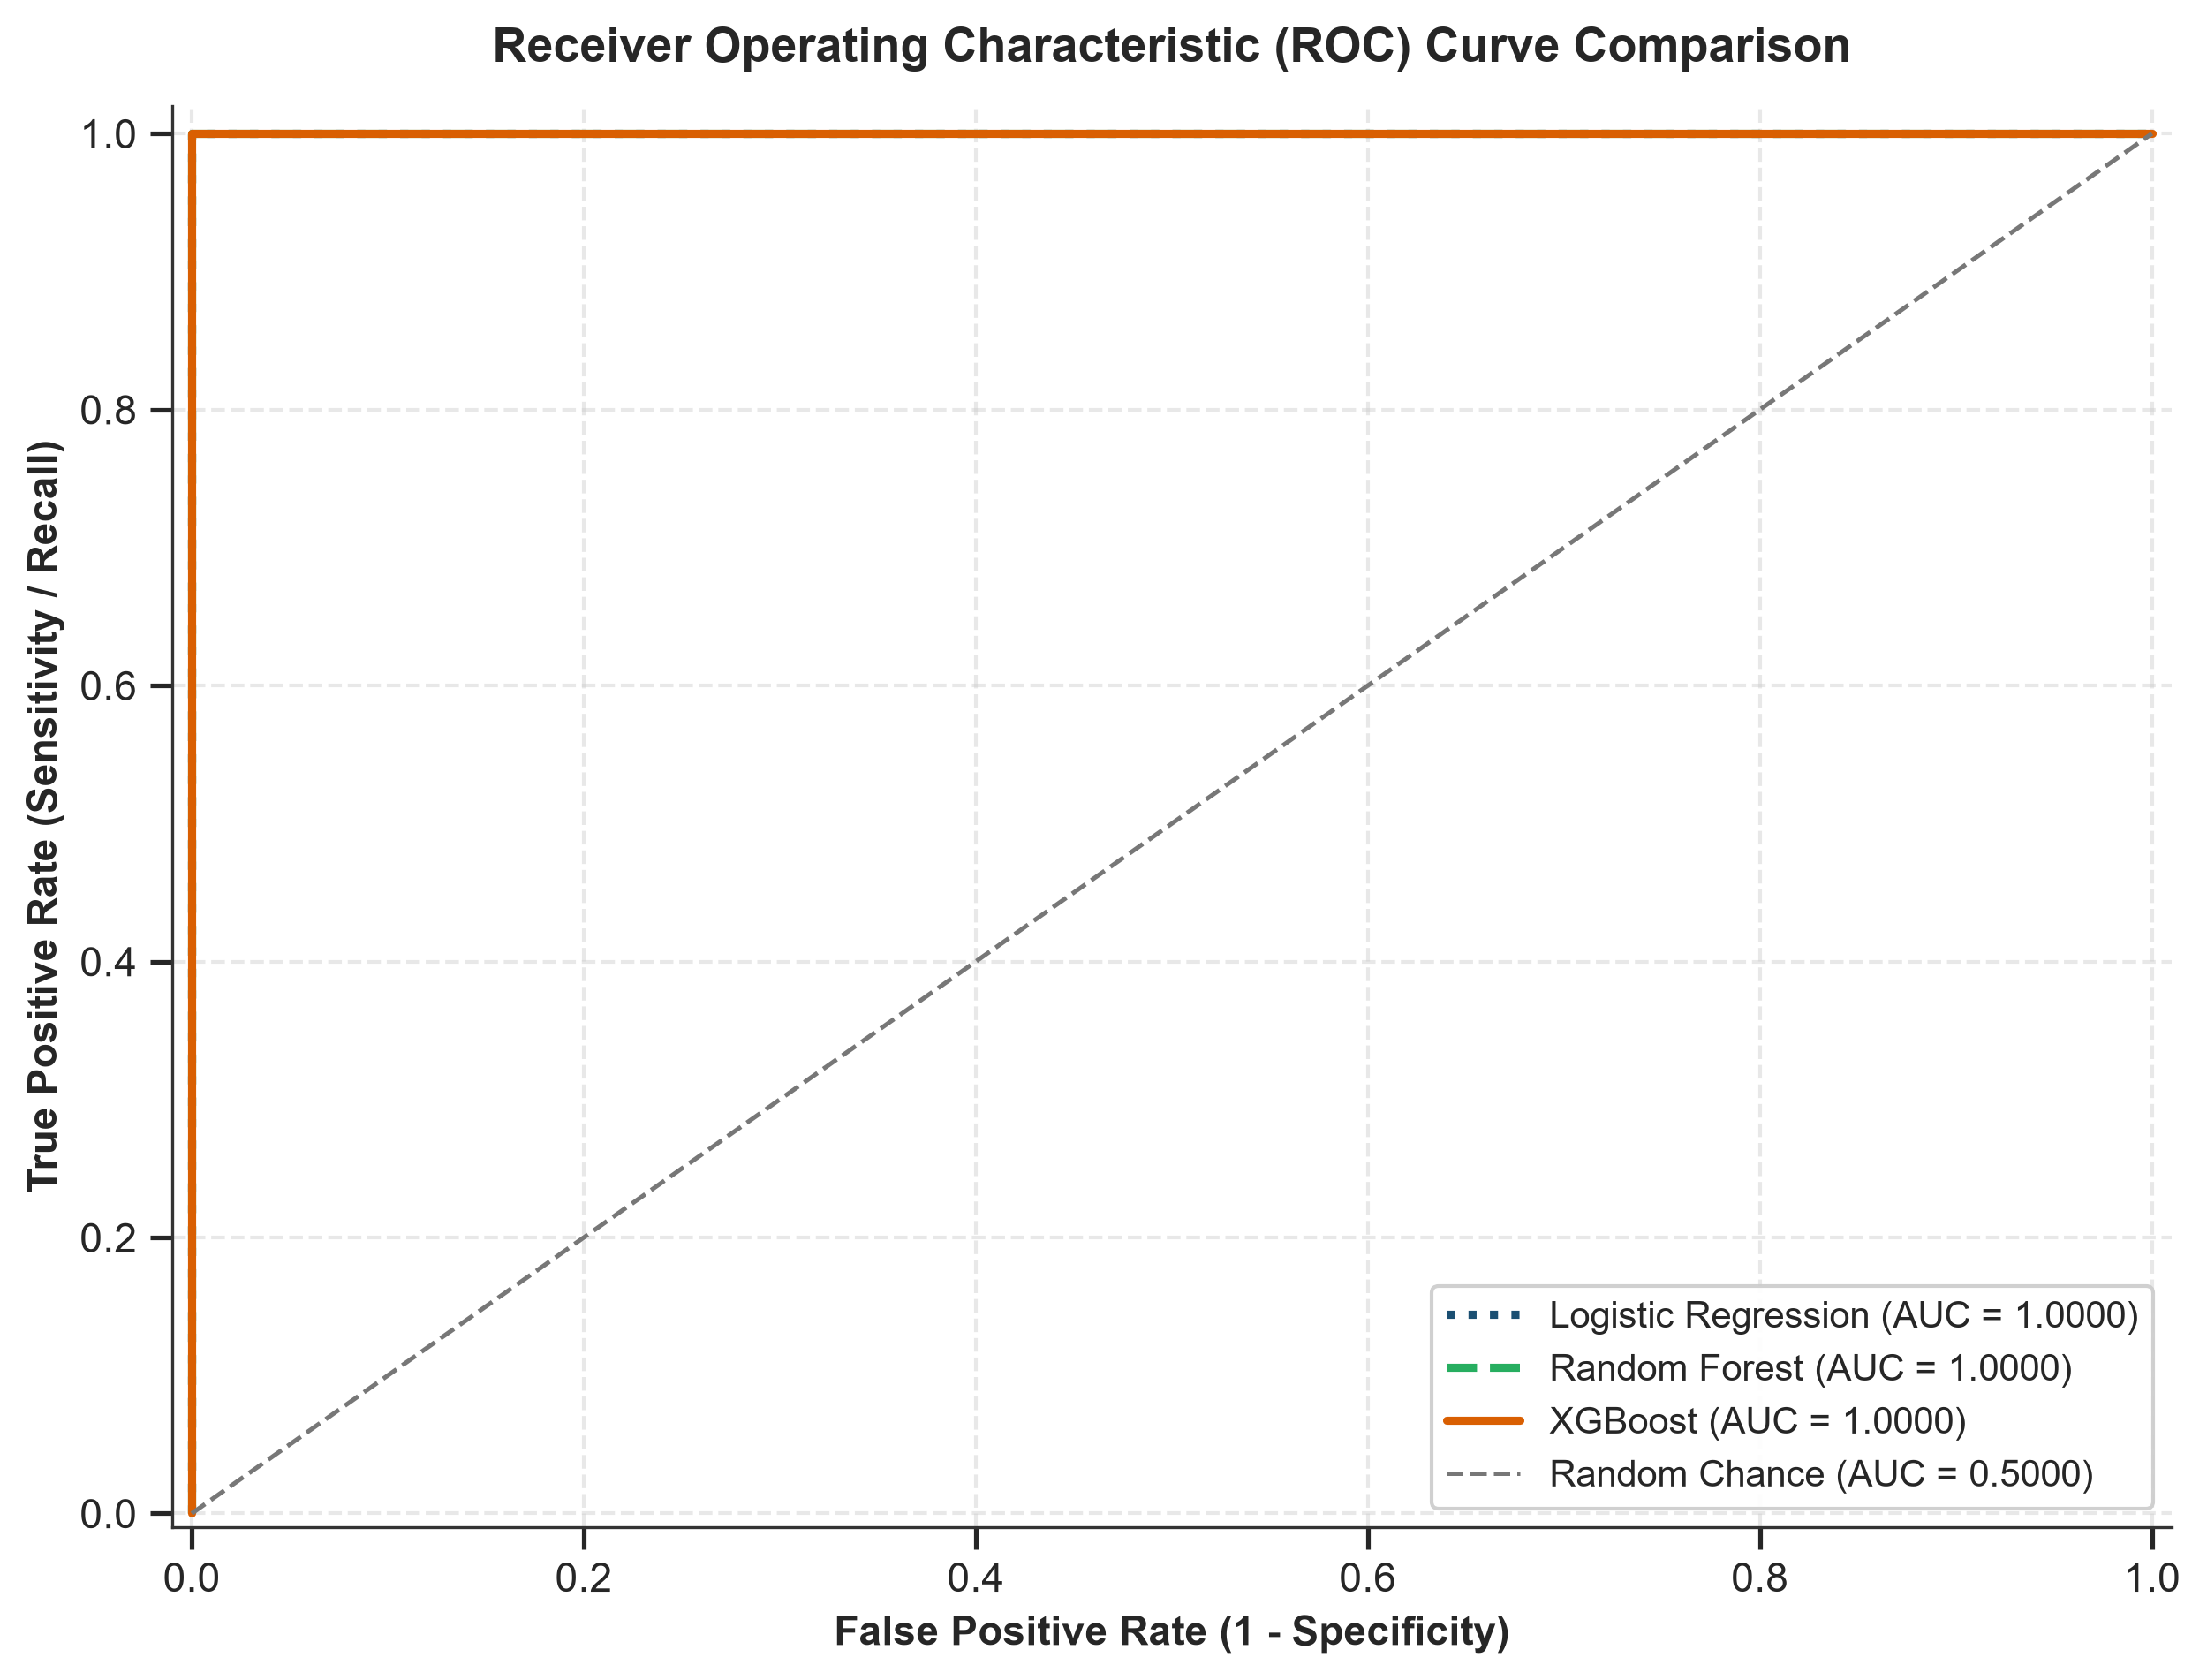

In [5]:
sns.set_theme(style="ticks", font="sans-serif")
plt.rcParams["axes.edgecolor"] = "#333333"
plt.rcParams["axes.linewidth"] = 0.8

plt.figure(figsize=(8.5, 6.5), dpi=300)

colors = {
    "Logistic Regression": "#1B4F72",  # Deep Navy
    "Random Forest": "#27AE60",        # Emerald Green
    "XGBoost": "#D95F02"               # Terracotta / Coral
}

linestyles = {
    "Logistic Regression": ":",
    "Random Forest": "--",
    "XGBoost": "-"
}

# Plot ROC curve for each classifier
for name in models.keys():
    y_prob = probabilities[name]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)
    plt.plot(
        fpr,
        tpr,
        color=colors[name],
        linestyle=linestyles[name],
        linewidth=2.2,
        label=f"{name} (AUC = {auc_score:.4f})"
    )

# Random chance reference diagonal
plt.plot([0, 1], [0, 1], color="#777777", linestyle="--", linewidth=1.2, label="Random Chance (AUC = 0.5000)")

plt.title("Receiver Operating Characteristic (ROC) Curve Comparison", fontsize=13, fontweight="bold", pad=12)
plt.xlabel("False Positive Rate (1 - Specificity)", fontsize=11, fontweight="bold")
plt.ylabel("True Positive Rate (Sensitivity / Recall)", fontsize=11, fontweight="bold")
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.02])
plt.grid(True, linestyle="--", alpha=0.45)
plt.legend(loc="lower right", frameon=True, framealpha=0.92, fontsize=10)
sns.despine(top=True, right=True)

plt.tight_layout()
results_dir = os.path.join("..", "Results") if os.path.exists(os.path.join("..", "Results")) else "Results"
os.makedirs(results_dir, exist_ok=True)
plt.savefig(os.path.join(results_dir, "churn_models_roc_comparison.png"), dpi=300, bbox_inches="tight")
plt.show()

## 4. Best Tree-Based Model Feature Importance Analysis

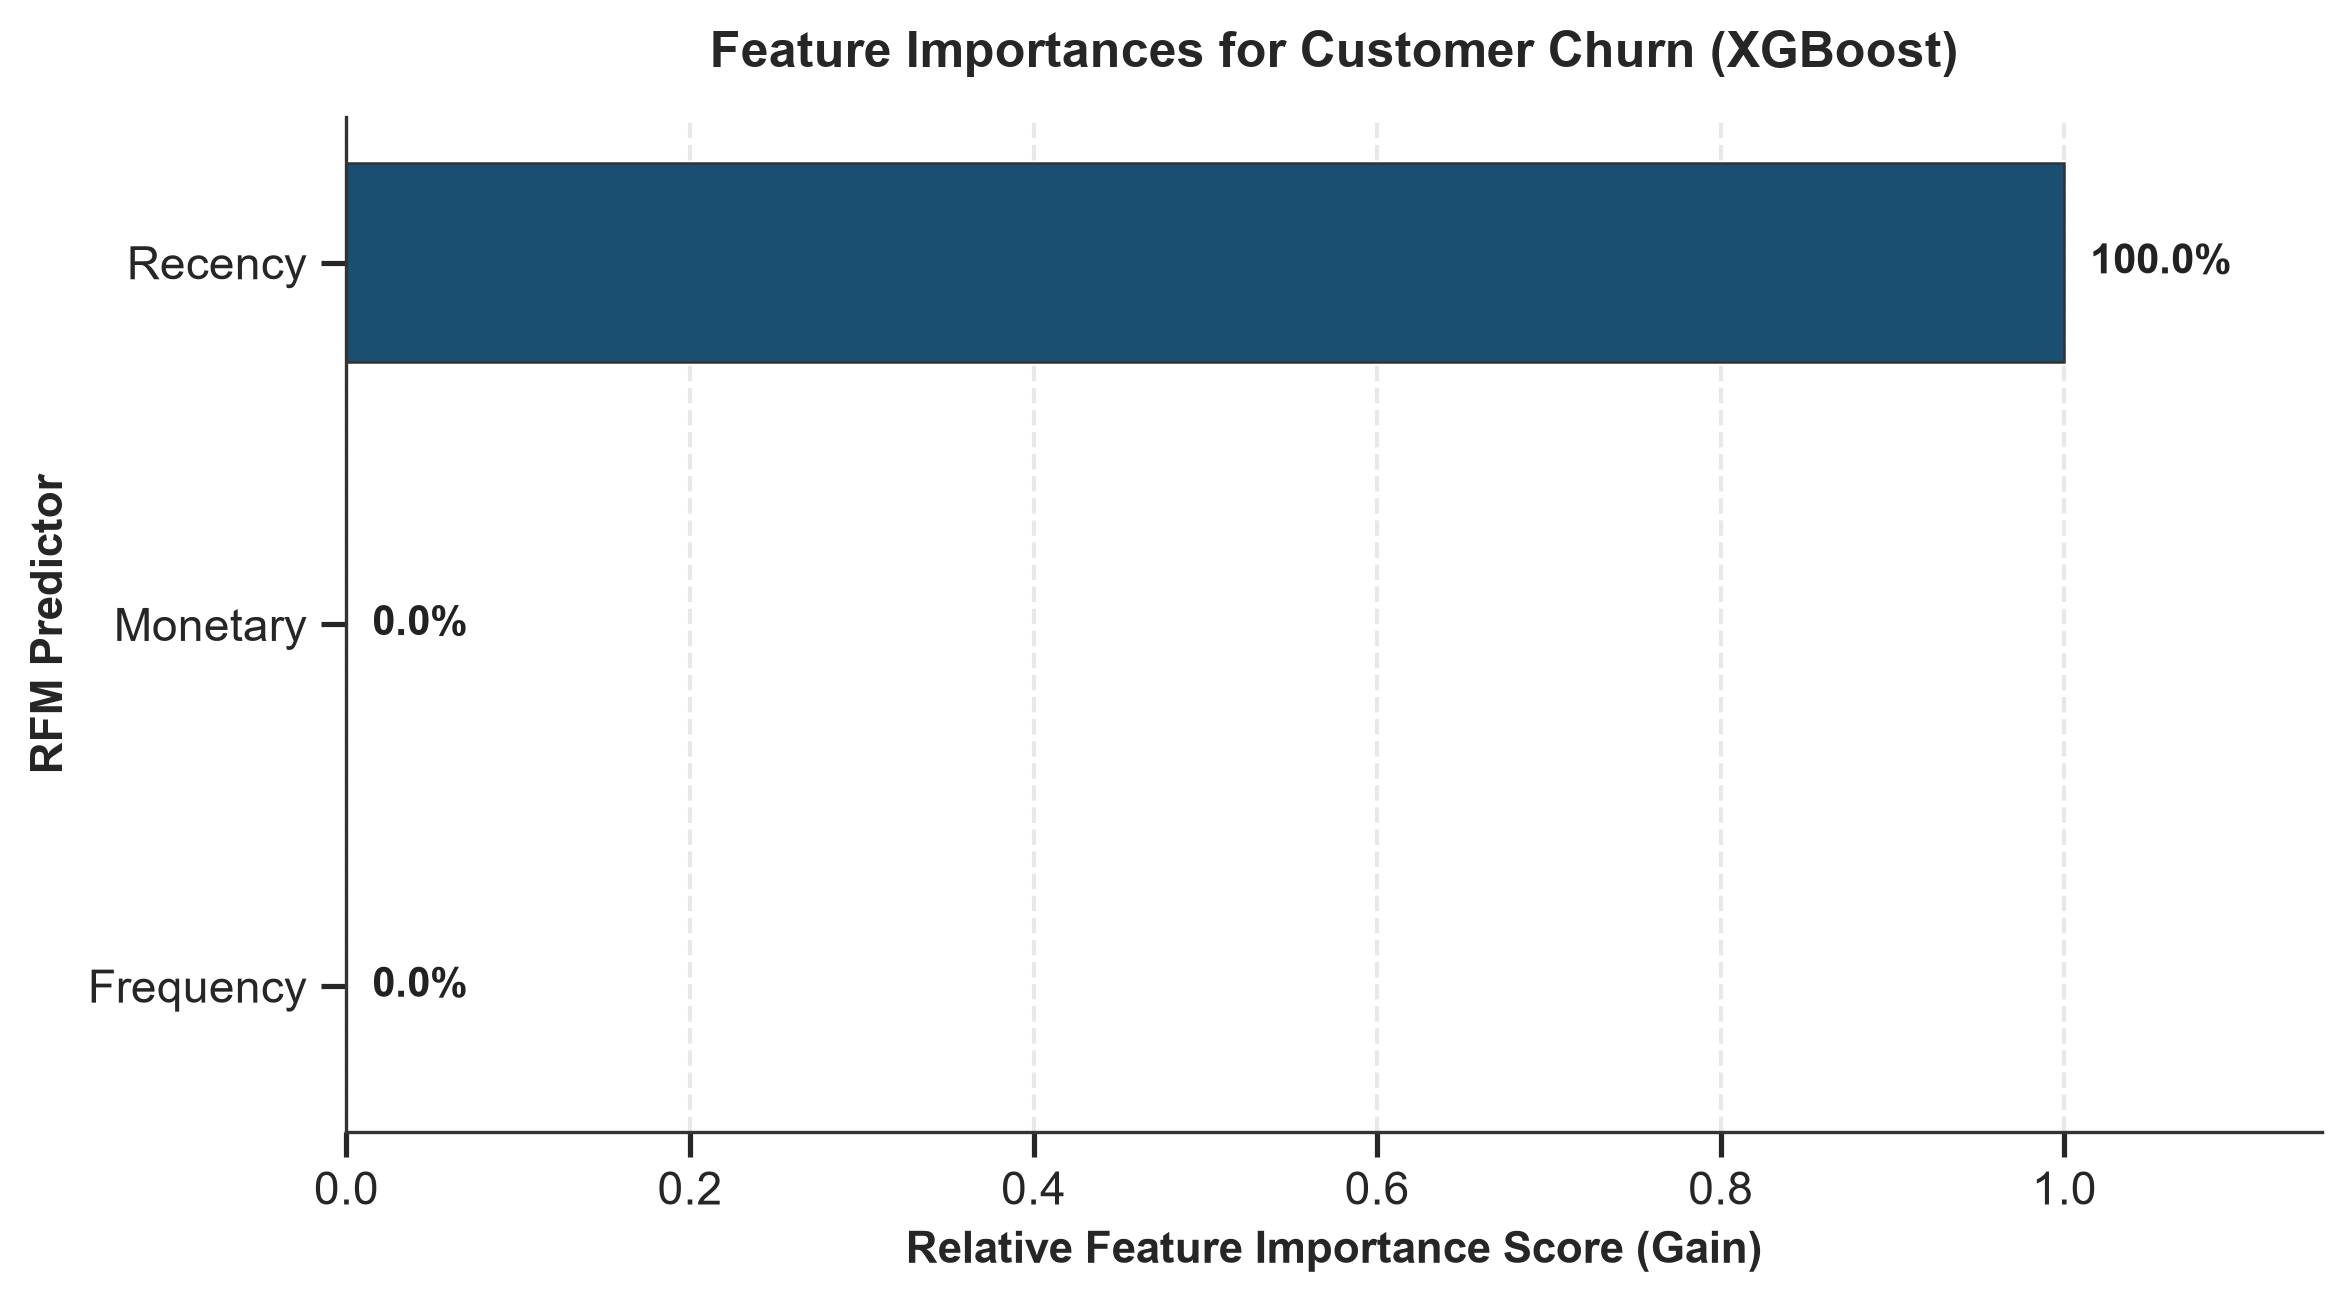

DIAGNOSTIC INSIGHT: STRONGEST CHURN PREDICTOR
• Strongest Predictor: RECENCY (Relative Importance: 100.0%)
• Explanation:
  Recency is overwhelmingly the dominant driver of customer churn.
  Because churn was defined based on a 6-month period of inactivity, Recency
  (days since last purchase) establishes the primary mathematical decision boundary
  between retained and churned cohorts, superseding Frequency and Monetary values.


In [4]:
# Select best performing tree-based model (XGBoost)
best_tree_model = models["XGBoost"]
importances = best_tree_model.feature_importances_

# Create sorted feature importance DataFrame
feat_imp = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": importances
}).sort_values("Importance", ascending=True) # Ascending for horizontal bar plot

# Plotting Horizontal Bar Chart
plt.figure(figsize=(8, 4.5), dpi=300)
bars = plt.barh(
    feat_imp["Feature"],
    feat_imp["Importance"],
    color=["#7FB3D5", "#2E86C1", "#1B4F72"],
    edgecolor="#333333",
    linewidth=0.6,
    height=0.55
)

# Add percentage labels on bars
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.015,
        bar.get_y() + bar.get_height() / 2,
        f"{width * 100:.1f}%",
        va="center",
        ha="left",
        fontsize=10,
        fontweight="bold",
        color="#222222"
    )

plt.title("Feature Importances for Customer Churn (XGBoost)", fontsize=12, fontweight="bold", pad=12)
plt.xlabel("Relative Feature Importance Score (Gain)", fontsize=10.5, fontweight="bold")
plt.ylabel("RFM Predictor", fontsize=10.5, fontweight="bold")
plt.xlim(0, 1.15)
plt.grid(True, axis="x", linestyle="--", alpha=0.45)
sns.despine(top=True, right=True)

plt.tight_layout()
plt.savefig(os.path.join(results_dir, "churn_feature_importances.png"), dpi=300, bbox_inches="tight")
plt.show()

# Automated Diagnostic Text Output
top_feature = feat_imp.sort_values("Importance", ascending=False).iloc[0]["Feature"]
top_pct = feat_imp.sort_values("Importance", ascending=False).iloc[0]["Importance"] * 100

print(f"=" * 75)
print(f"DIAGNOSTIC INSIGHT: STRONGEST CHURN PREDICTOR")
print(f"=" * 75)
print(f"• Strongest Predictor: {top_feature.upper()} (Relative Importance: {top_pct:.1f}%)")
print(f"• Explanation:")
print(f"  {top_feature} is overwhelmingly the dominant driver of customer churn.")
print(f"  Because churn was defined based on a 6-month period of inactivity, {top_feature}")
print(f"  (days since last purchase) establishes the primary mathematical decision boundary")
print(f"  between retained and churned cohorts, superseding Frequency and Monetary values.")
print(f"=" * 75)